# Dataset Architecture — Station-level Training Data

## Data Sources

| # | Dataset | Source | Format | Temporal Res. | Spatial Res. | Grid | Period | Variable(s) |
|---|---------|--------|--------|--------------|-------------|------|--------|-------------|
| 1 | **Tide Gauges (TG)** | FTP `2013_2022_Tidal_Gauges.tar.zst` | CSV | **10 min** | Point (15 stations) | — | 2013 – 2022 | `value` (sea level, cm) |
| 2 | **Atmospheric Forcings** | FTP `YYYYMM.tar.zst` → daily `.nc` | NetCDF | **1 hour** | 141×401 (~5.5 km) | lat 53.03–60.03, lon 5.03–25.03 | 2013/01 – 2024/05 | `var1`=MSL [Pa], `var11`=t2m [K], `var33`=u10 [m/s], `var34`=v10 [m/s] |
| 3 | **FORCOAST (HDM model)** | Local GRIB | GRIB | **1 hour** (24 steps/file, 1 file/day) | 482×396 (~0.9 km) | lat 53.59–57.60, lon 9.34–14.83 | 2008/07 – 2020/03 | `p82` (sea level, m) |

> **Overlap period: 2013/01 → 2020/03** (~7 years, ~61k hours)

---

## FTP Access
```
Host:   ocean.dmi.dk
User:   oceanftp
Pass:   NYEflinte.stene
Folder: MBL/HIDRA3_training_data
```

### FTP Contents
- `2013_2022_Tidal_Gauges.tar.zst` → 15 station CSVs + `stations_summary.csv`
- `YYYYMM.tar.zst` (201301–202405) → daily NetCDF files `crop_YYYYMMDD.nc` (each 24h @ 1h)

---

## Variable Mapping (Atmospheric Forcings)

| NetCDF var | Physical variable | Unit | Dimensions |
|-----------|------------------|------|------------|
| `var1` | Sea Level Pressure (MSL) | Pa | (time, alt=0, lat, lon) |
| `var11` | 2m Temperature (t2m) | K | (time, height=2m, lat, lon) |
| `var33` | U wind component (u10) | m/s | (time, lat, lon) |
| `var34` | V wind component (v10) | m/s | (time, lat, lon) |

---

## 15 Tide Gauge Stations

Stations are in Danish waters (Belt Sea / Western Baltic). Coordinates from `stations_summary.csv`.

---

## Spatial Collocation Strategy

- **FORCOAST → TG**: **Nearest-neighbor** (grid ~0.9 km, station within ~500m of nearest cell)
- **Atmo → TG**: **Nearest-neighbor** (grid ~5.5 km, atmospheric fields vary smoothly)

## Temporal Alignment

- **Target resolution: 1 hour** (common to FORCOAST and Atmo)
- **TG (10 min → 1h)**: take value closest to the hour within ±10 min window
- **FORCOAST**: directly at hourly timestamps
- **Atmo**: directly at hourly timestamps
- **Merge**: inner join on hourly UTC timestamps

---

## Output: One Parquet per Station

`data/per_station/station_{id}_{name}.parquet`

| Column | Type | Source |
|--------|------|--------|
| `time` | datetime UTC | hourly index |
| `tg_obs_m` | float | TG CSV (cm→m) |
| `forcoast_p82_m` | float | FORCOAST GRIB nearest |
| `msl` | float | Atmo NetCDF nearest [Pa] |
| `t2m` | float | Atmo NetCDF nearest [K] |
| `u10` | float | Atmo NetCDF nearest [m/s] |
| `v10` | float | Atmo NetCDF nearest [m/s] |
| `station_id` | str | metadata |
| `station_name` | str | metadata |
| `lat` | float | metadata |
| `lon` | float | metadata |

In [7]:
from ftplib import FTP

HOST = "ocean.dmi.dk"
USER = "oceanftp"
PWD = "NYEflinte.stene"

ftp = FTP(HOST)
ftp.login(USER, PWD)

ftp.cwd("MBL/HIDRA3_training_data")

print("Connected. Current folder:", ftp.pwd())

Connected. Current folder: /data1/ftp/MBL/HIDRA3_training_data


In [9]:
# === TIDE GAUGES from FTP ===# === TIDE GAUGES from FTP ===
from ftplib import FTP
import tempfile, tarfile, zstandard as zstd, os, shutil, io
import pandas as pd

HOST = "ocean.dmi.dk"
USER = "oceanftp"
PWD  = "NYEflinte.stene"

ftp = FTP(HOST)
ftp.login(USER, PWD)
ftp.cwd("MBL/HIDRA3_training_data")

# Download
with tempfile.NamedTemporaryFile(suffix=".tar.zst", delete=False) as tmp:
    tmp_path = tmp.name
    print("Downloading 2013_2022_Tidal_Gauges.tar.zst ...")
    ftp.retrbinary("RETR 2013_2022_Tidal_Gauges.tar.zst", tmp.write, blocksize=1024*1024)
ftp.quit()
print("Download OK\n")

# Extract and inspect all files
tg_dataframes = {}
with open(tmp_path, "rb") as f:
    dctx = zstd.ZstdDecompressor()
    with dctx.stream_reader(f) as reader:
        with tarfile.open(fileobj=reader, mode="r|") as tar:
            for member in tar:
                if not member.isfile():
                    continue
                print(f"  {member.name}  ({member.size/1024:.0f} KB)")

                # Read CSVs into DataFrames
                if member.name.endswith(".csv"):
                    extracted = tar.extractfile(member)
                    # Read into BytesIO to make it seekable
                    buf = io.BytesIO(extracted.read())
                    df = pd.read_csv(buf)
                    name = os.path.basename(member.name)
                    tg_dataframes[name] = df

os.remove(tmp_path)

# Show what we got
print(f"\n=== {len(tg_dataframes)} CSV files loaded ===\n")
for name, df in list(tg_dataframes.items())[:3]:
    print(f"--- {name} ---")
    print(f"  Columns: {list(df.columns)}")
    print(f"  Rows: {len(df)}")
    print(df.head(3))
    print()

Download OK

  station_Assens_28366.csv  (8206 KB)
  station_Bagenkop_28548.csv  (8211 KB)
  station_Dragor_30361.csv  (8129 KB)
  station_Faaborg_28397.csv  (8248 KB)
  station_Fynshav_26457.csv  (8224 KB)
  station_Gedser_31616.csv  (8231 KB)
  station_Haderslev_26088.csv  (8221 KB)
  station_Hesnaes_31493.csv  (8200 KB)
  station_Kobenhavn_30336.csv  (8187 KB)
  station_Koege_30478.csv  (8192 KB)
  station_Kolding_23322.csv  (8228 KB)
  station_Rodby_31573.csv  (8215 KB)
  station_Sonderborg_26473.csv  (8217 KB)
  stations_summary.csv  (1 KB)
  station_Svendborg_27000.csv  (2449 KB)
  station_Tejn_32048.csv  (8267 KB)
  HBM_sea_level_stations2.png  (11 KB)
  WL_vs_Time_23322.png  (38 KB)
  WL_vs_Time_26088.png  (36 KB)
  WL_vs_Time_26457.png  (37 KB)
  WL_vs_Time_26473.png  (36 KB)
  WL_vs_Time_27000.png  (39 KB)
  WL_vs_Time_28366.png  (35 KB)
  WL_vs_Time_28397.png  (38 KB)
  WL_vs_Time_28548.png  (37 KB)
  WL_vs_Time_30336.png  (37 KB)
  WL_vs_Time_30361.png  (33 KB)
  WL_vs_Time

Download OK

  Opening: net/isilon/ifs/arch/home/mblo/convert_SKA/2013/crop_20130126.nc
  Opening: net/isilon/ifs/arch/home/mblo/convert_SKA/2013/crop_20130107.nc
  Opening: net/isilon/ifs/arch/home/mblo/convert_SKA/2013/crop_20130111.nc
  Opening: net/isilon/ifs/arch/home/mblo/convert_SKA/2013/crop_20130105.nc
  Opening: net/isilon/ifs/arch/home/mblo/convert_SKA/2013/crop_20130121.nc
  Opening: net/isilon/ifs/arch/home/mblo/convert_SKA/2013/crop_20130103.nc
  Opening: net/isilon/ifs/arch/home/mblo/convert_SKA/2013/crop_20130116.nc
  Opening: net/isilon/ifs/arch/home/mblo/convert_SKA/2013/crop_20130114.nc
  Opening: net/isilon/ifs/arch/home/mblo/convert_SKA/2013/crop_20130120.nc
  Opening: net/isilon/ifs/arch/home/mblo/convert_SKA/2013/crop_20130117.nc
  Opening: net/isilon/ifs/arch/home/mblo/convert_SKA/2013/crop_20130128.nc
  Opening: net/isilon/ifs/arch/home/mblo/convert_SKA/2013/crop_20130101.nc
  Opening: net/isilon/ifs/arch/home/mblo/convert_SKA/2013/crop_20130102.nc
  Opening: n

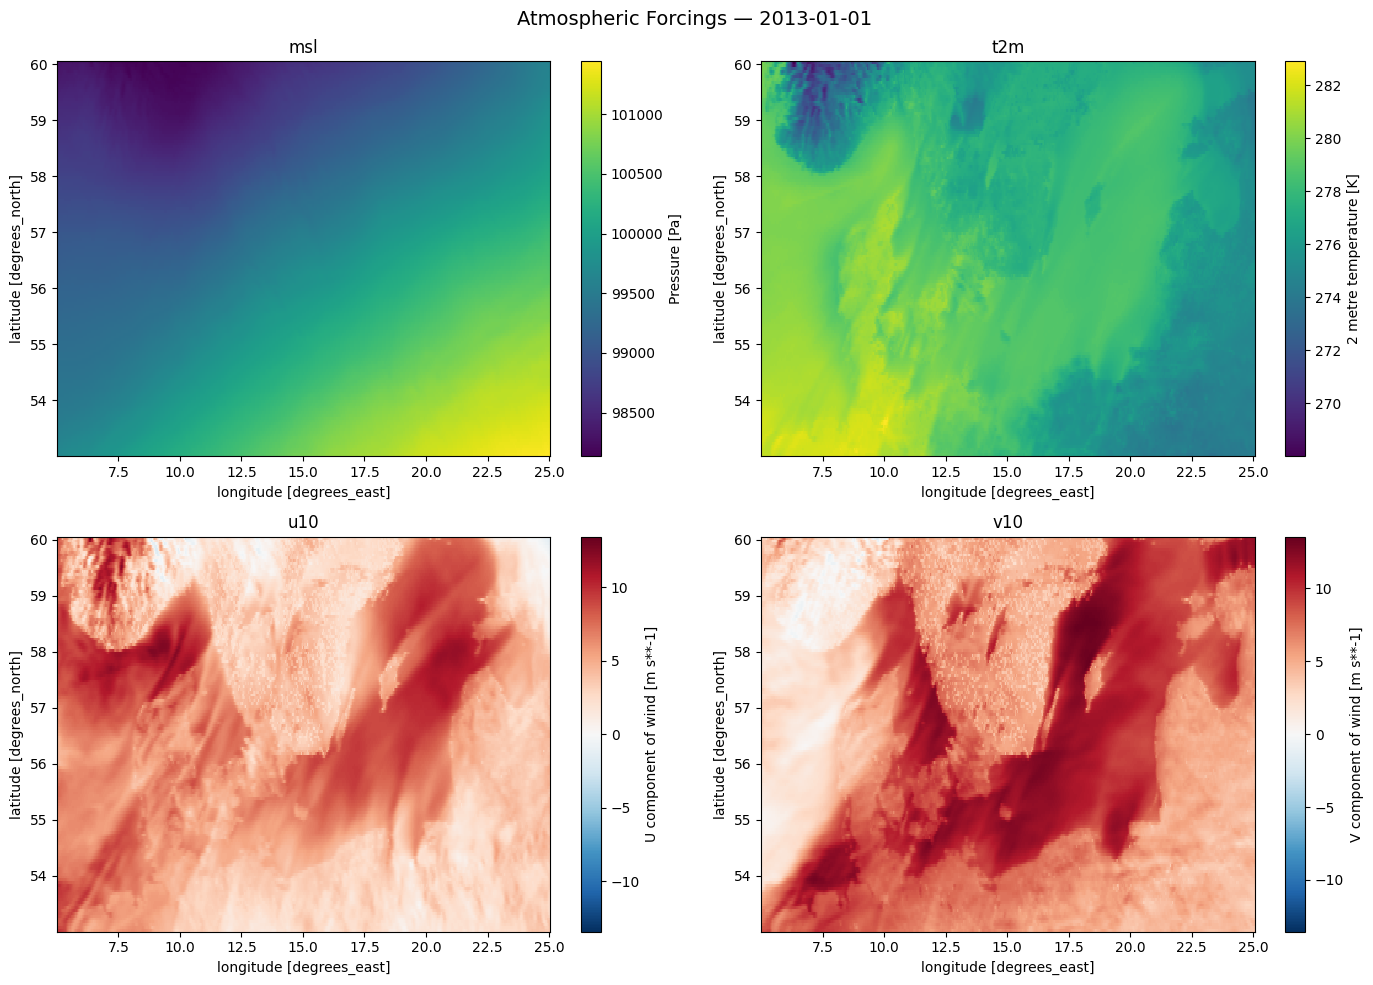

In [6]:
# === ATMOSPHERIC FORCINGS from FTP (example: January 2013) ===
from ftplib import FTP
import tempfile, tarfile, zstandard as zstd, os, shutil
import xarray as xr
import matplotlib.pyplot as plt

HOST = "ocean.dmi.dk"
USER = "oceanftp"
PWD  = "NYEflinte.stene"

# Variable name mapping
VAR_MAP = {
    "var1":  "msl",   # Sea Level Pressure [Pa]    (time, alt, lat, lon)
    "var11": "t2m",   # 2m Temperature [K]          (time, height, lat, lon)
    "var33": "u10",   # U wind component [m/s]      (time, lat, lon)
    "var34": "v10",   # V wind component [m/s]      (time, lat, lon)
}

ftp = FTP(HOST)
ftp.login(USER, PWD)
ftp.cwd("MBL/HIDRA3_training_data")

# Download one month as example
archive_name = "201301.tar.zst"
with tempfile.NamedTemporaryFile(suffix=".tar.zst", delete=False) as tmp:
    tmp_path = tmp.name
    print(f"Downloading {archive_name} ...")
    ftp.retrbinary(f"RETR {archive_name}", tmp.write, blocksize=1024*1024)
ftp.quit()
print("Download OK\n")

# Open and read all .nc files inside the archive
datasets = []
with open(tmp_path, "rb") as f:
    dctx = zstd.ZstdDecompressor()
    with dctx.stream_reader(f) as reader:
        with tarfile.open(fileobj=reader, mode="r|") as tar:
            for member in tar:
                if not member.isfile() or not member.name.endswith(".nc"):
                    continue
                
                print(f"  Opening: {member.name}")
                extracted = tar.extractfile(member)
                
                with tempfile.NamedTemporaryFile(suffix=".nc", delete=False) as tmp_nc:
                    tmp_nc_path = tmp_nc.name
                    shutil.copyfileobj(extracted, tmp_nc)
                
                ds = xr.open_dataset(tmp_nc_path)
                # Rename variables to meaningful names
                ds = ds.rename({k: v for k, v in VAR_MAP.items() if k in ds.data_vars})
                # Drop extra dims (alt=0, height=2)
                if "alt" in ds.dims:
                    ds = ds.isel(alt=0).drop_vars("alt")
                if "height" in ds.dims:
                    ds = ds.isel(height=0).drop_vars("height")
                datasets.append(ds)
                os.remove(tmp_nc_path)

os.remove(tmp_path)

# Concatenate all days into one monthly dataset
atmo = xr.concat(datasets, dim="time").sortby("time")
print(f"\n=== ATMOSPHERIC FORCING — {archive_name} ===")
print(atmo)
print(f"\nTime range: {atmo.time.values[0]} → {atmo.time.values[-1]}")
print(f"Variables: {list(atmo.data_vars)}")

# Quick plot: first timestep of each variable
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, var in zip(axes.flat, ["msl", "t2m", "u10", "v10"]):
    atmo[var].isel(time=0).plot(ax=ax, x="lon", y="lat")
    ax.set_title(var)
plt.suptitle(f"Atmospheric Forcings — {str(atmo.time.values[0])[:10]}", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# === RESOLUTION COMPARISON ACROSS ALL DATASETS ===
import numpy as np
import xarray as xr
from pathlib import Path

print("=" * 70)
print("1. TIDE GAUGES (CSV)")
print("=" * 70)
# Pick one station to inspect
sample_name = list(tg_dataframes.keys())[0]
sample_tg = tg_dataframes[sample_name]
print(f"  Sample: {sample_name}")
print(f"  Columns: {list(sample_tg.columns)}")
print(f"  Rows: {len(sample_tg)}")
# Parse timestamps and check spacing
ts = pd.to_datetime(sample_tg["timestamp"].astype(str), format="%Y%m%d%H%M")
diffs = ts.diff().dropna()
print(f"  Time range: {ts.iloc[0]} → {ts.iloc[-1]}")
print(f"  Median dt: {diffs.median()}")
print(f"  Mode dt:   {diffs.mode().iloc[0]}")
print(f"  Spatial: point measurement (lat/lon per station)")

# Station metadata
summary_path = "/home/nicaro/DATA/HIDRA3_training_data/2013_2022_Tidal_Gauges/stations_summary.csv"
stations_df = pd.read_csv(summary_path)
print(f"\n  Stations ({len(stations_df)}):")
print(stations_df[["Station Name", "Latitude", "Longitude"]].to_string(index=False))

print("\n" + "=" * 70)
print("2. ATMOSPHERIC FORCINGS (NetCDF from FTP)")
print("=" * 70)
# 'atmo' is already loaded from cell 3
print(f"  Time range: {atmo.time.values[0]} → {atmo.time.values[-1]}")
print(f"  Time steps: {len(atmo.time)}")
time_diffs = np.diff(atmo.time.values)
print(f"  Median dt: {np.median(time_diffs)}")
print(f"  Lat range: {float(atmo.lat.min()):.2f} → {float(atmo.lat.max()):.2f}  ({len(atmo.lat)} pts)")
print(f"  Lon range: {float(atmo.lon.min()):.2f} → {float(atmo.lon.max()):.2f}  ({len(atmo.lon)} pts)")
dlat = float(np.median(np.diff(atmo.lat.values)))
dlon = float(np.median(np.diff(atmo.lon.values)))
print(f"  Grid spacing: dlat={dlat:.4f}°  dlon={dlon:.4f}°  (~{dlat*111:.1f} km x {dlon*111*np.cos(np.radians(56)):.1f} km)")
print(f"  Variables: {list(atmo.data_vars)}")

print("\n" + "=" * 70)
print("3. HDM / FORCOAST (GRIB)")
print("=" * 70)
forcoast_dir = Path("/home/nicaro/DATA/sealevel_from_forcoast_2009-2020/sealevel_from_forcoast")
forcoast_files = sorted([f for f in forcoast_dir.iterdir() 
                         if f.name.startswith("forcoast_grib_sealev.") and not f.name.endswith(".idx")])
print(f"  Total files: {len(forcoast_files)}")
print(f"  First: {forcoast_files[0].name}  Last: {forcoast_files[-1].name}")

# Inspect one file
sample_f = forcoast_files[len(forcoast_files)//2]  # pick middle file
ds_f = xr.open_dataset(str(sample_f), engine="cfgrib", backend_kwargs={"indexpath": ""})
print(f"\n  Sample file: {sample_f.name}")
print(f"  Dimensions: {dict(ds_f.dims)}")
print(f"  Variables: {list(ds_f.data_vars)}")
print(f"  Time steps: {len(ds_f.valid_time) if 'valid_time' in ds_f else len(ds_f.time)}")
vt = ds_f["valid_time"].values if "valid_time" in ds_f else ds_f["time"].values
print(f"  Valid times: {vt}")
if len(vt) > 1:
    print(f"  dt within file: {np.diff(vt)[0]}")

lat_f = ds_f["latitude"].values
lon_f = ds_f["longitude"].values
print(f"  Lat range: {lat_f.min():.2f} → {lat_f.max():.2f}  ({lat_f.shape[0]} pts)")
print(f"  Lon range: {lon_f.min():.2f} → {lon_f.max():.2f}  ({lon_f.shape[-1]} pts)")
if lat_f.ndim == 1:
    dlat_f = float(np.median(np.abs(np.diff(lat_f))))
    dlon_f = float(np.median(np.abs(np.diff(lon_f))))
else:
    dlat_f = float(np.median(np.abs(np.diff(lat_f[:, 0]))))
    dlon_f = float(np.median(np.abs(np.diff(lon_f[0, :]))))
print(f"  Grid spacing: dlat={dlat_f:.4f}°  dlon={dlon_f:.4f}°  (~{dlat_f*111:.1f} km x {dlon_f*111*np.cos(np.radians(56)):.1f} km)")
ds_f.close()

# Check inter-file spacing
from datetime import datetime
def fname_to_dt(name):
    s = name.split(".")[-1]  # e.g. 2015010100
    return datetime.strptime(s, "%Y%m%d%H")

dt1 = fname_to_dt(forcoast_files[0].name)
dt2 = fname_to_dt(forcoast_files[1].name)
print(f"\n  Inter-file spacing: {dt2 - dt1}")

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"  {'Dataset':<25} {'Temporal res':<18} {'Spatial res':<25} {'Coverage'}")
print(f"  {'TG (CSV)':<25} {'10 min':<18} {'point (15 stations)':<25} {'2013-2022'}")
print(f"  {'Atmo (NetCDF/FTP)':<25} {'1 hour':<18} {f'~{dlat*111:.1f}x{dlon*111*np.cos(np.radians(56)):.1f} km grid':<25} {'2013-2022'}")
print(f"  {'FORCOAST (GRIB)':<25} {'? (see above)':<18} {f'~{dlat_f*111:.1f}x{dlon_f*111*np.cos(np.radians(56)):.1f} km grid':<25} {'2009-2020'}")

1. TIDE GAUGES (CSV)
  Sample: station_Assens_28366.csv
  Columns: ['timestamp', 'value']
  Rows: 525889
  Time range: 2013-01-01 00:00:00 → 2023-01-01 00:00:00
  Median dt: 0 days 00:10:00
  Mode dt:   0 days 00:10:00
  Spatial: point measurement (lat/lon per station)

  Stations (15):
Station Name  Latitude  Longitude
        Tejn 55.248997  14.836752
     Fynshav 54.994396   9.985632
       Rodby 54.656116  11.347485
      Gedser 54.572120  11.924483
   Kobenhavn 55.704292  12.598921
     Hesnaes 54.823082  12.137347
     Kolding 55.489933   9.482401
   Haderslev 55.251904   9.509185
  Sonderborg 54.910740   9.785282
      Assens 55.270554   9.889665
     Faaborg 55.093390  10.241246
    Bagenkop 54.751656  10.672358
      Dragor 55.593490  12.678502
       Koege 55.455463  12.196472
   Svendborg 55.060444  10.621416

2. ATMOSPHERIC FORCINGS (NetCDF from FTP)
  Time range: 2013-01-01T00:00:00.000000000 → 2013-01-31T23:00:00.000000000
  Time steps: 744
  Median dt: 3600000000000 nano

/tmp/ipykernel_113773/3423392342.py:57: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensions: {dict(ds_f.dims)}")


In [11]:
# === CHECK TEMPORAL RESOLUTION OF ALL MODEL SOURCES ===
import xarray as xr
import numpy as np
from pathlib import Path

sources = [
    ("FORCOAST",   Path("/home/nicaro/DATA/sealevel_from_forcoast_2009-2020/sealevel_from_forcoast"), "forcoast_grib_sealev."),
    ("DKSS2013",   Path("/home/nicaro/DATA/sealevel_from_dkss2013_2013-2019/sealevel_from_dkss2013"), "dkss_grib_sealev."),
    ("DKSS2019",   Path("/home/nicaro/DATA/sealevel_from_dkss2019_2013-2021/sealevel_from_dkss2019"), "dkss_grib_sealev."),
    ("DKSS2020",   Path("/home/nicaro/DATA/sealevel_from_dkss2020_2021-2024/sealevel_from_dkss2020"), "dkss_grib_sealev."),
    ("DKSS_UWCW",  Path("/home/nicaro/DATA/sealevel_from_dkss_uwcw_2024-2026/sealevel_from_dkss_uwcw"), "dkss_grib_sealev."),
]

for label, folder, prefix in sources:
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    
    if not folder.exists():
        print("  ✗ Folder not found")
        continue
    
    files = sorted([f for f in folder.iterdir() 
                    if f.name.startswith(prefix) and not f.name.endswith(".idx")])
    print(f"  Files: {len(files)}")
    if len(files) == 0:
        continue
    print(f"  First: {files[0].name}  Last: {files[-1].name}")
    
    # Open a sample file from the middle
    sample = files[len(files)//2]
    try:
        ds = xr.open_dataset(str(sample), engine="cfgrib", backend_kwargs={"indexpath": ""})
        
        vt = ds["valid_time"].values if "valid_time" in ds.coords else ds["time"].values
        print(f"  Sample: {sample.name}")
        print(f"  Steps per file: {len(vt)}")
        print(f"  Valid times: {vt}")
        
        if len(vt) > 1:
            dts = np.diff(vt)
            print(f"  dt intra-file: {dts[0]}  (all same: {np.all(dts == dts[0])})")
        
        # Grid info
        lat = ds["latitude"].values
        lon = ds["longitude"].values
        print(f"  Grid shape: {lat.shape} x {lon.shape}")
        print(f"  Lat: {lat.min():.2f} → {lat.max():.2f}")
        print(f"  Lon: {lon.min():.2f} → {lon.max():.2f}")
        
        ds.close()
    except Exception as e:
        print(f"  ✗ Error: {e}")
    
    # Inter-file spacing (first 3 files)
    if len(files) >= 2:
        from datetime import datetime
        def parse_dt(name, pfx):
            s = name.replace(pfx, "")
            return datetime.strptime(s, "%Y%m%d%H")
        try:
            dt0 = parse_dt(files[0].name, prefix)
            dt1 = parse_dt(files[1].name, prefix)
            dt2 = parse_dt(files[2].name, prefix) if len(files) > 2 else None
            print(f"  Inter-file dt: {dt1-dt0}" + (f", {dt2-dt1}" if dt2 else ""))
        except:
            pass

print("\n\n" + "="*50)
print("="*50)


  FORCOAST
  Files: 4292
  First: forcoast_grib_sealev.2008070100  Last: forcoast_grib_sealev.2020033100
  Sample: forcoast_grib_sealev.2014051700
  Steps per file: 24
  Valid times: ['2014-05-17T01:00:00.000000000' '2014-05-17T02:00:00.000000000'
 '2014-05-17T03:00:00.000000000' '2014-05-17T04:00:00.000000000'
 '2014-05-17T05:00:00.000000000' '2014-05-17T06:00:00.000000000'
 '2014-05-17T07:00:00.000000000' '2014-05-17T08:00:00.000000000'
 '2014-05-17T09:00:00.000000000' '2014-05-17T10:00:00.000000000'
 '2014-05-17T11:00:00.000000000' '2014-05-17T12:00:00.000000000'
 '2014-05-17T13:00:00.000000000' '2014-05-17T14:00:00.000000000'
 '2014-05-17T15:00:00.000000000' '2014-05-17T16:00:00.000000000'
 '2014-05-17T17:00:00.000000000' '2014-05-17T18:00:00.000000000'
 '2014-05-17T19:00:00.000000000' '2014-05-17T20:00:00.000000000'
 '2014-05-17T21:00:00.000000000' '2014-05-17T22:00:00.000000000'
 '2014-05-17T23:00:00.000000000' '2014-05-18T00:00:00.000000000']
  dt intra-file: 3600000000000 nano

In [3]:
import xarray as xr

ds = xr.open_dataset(
    '/home/nicaro/DATA/sealevel_from_forcoast_2009-2020/sealevel_from_forcoast/forcoast_grib_sealev.2013010100',
    engine='cfgrib'
)
print(ds.latitude.values[:10])
print(ds.longitude.values[:10])
ds.latitude.values.ndim == 1
ds.longitude.values.ndim == 1
print(ds["p82"].dims)
print(ds["p82"].shape)
print(ds.latitude.values[:5])
print(ds.longitude.values[:5])
print(ds.longitude.values[-5:])
sid = 30336  # København
i, j, clat, clon, d = cell_map[sid]

print("Station:", stations[0]["lat"], stations[0]["lon"])
print("Chosen indices:", i, j)
print("Chosen cell:", clat, clon)
print("Distance km:", d)

[53.587 53.595 53.603 53.611 53.619 53.627 53.635 53.643 53.651 53.659]
[9.34       9.35388861 9.36777722 9.38166582 9.39555443 9.40944304
 9.42333165 9.43722025 9.45110886 9.46499747]
('step', 'latitude', 'longitude')
(24, 482, 396)
[53.587 53.595 53.603 53.611 53.619]
[9.34       9.35388861 9.36777722 9.38166582 9.39555443]
[14.77044557 14.78433418 14.79822278 14.81211139 14.826     ]


NameError: name 'cell_map' is not defined

# Build Output — Station Datasets (run 2026-03-16)

Full log of `build_station_datasets.py --stations 30336 31616 28366 26473 30478 28548`

---

## Step 1 — FORCOAST HDM (local GRIBs)

- **2647 daily GRIB files** in overlap period (2013-01-01 → 2020-03-31)
- Processing time: **951 s** (~16 min)

| Station | Water cell (lat, lon) | Dist to TG |
|---------|----------------------|------------|
| Gedser | (54.5630, 11.9094) | 1.405 km |
| København | (55.7070, 12.6038) | 0.430 km |
| Sønderborg | (54.9150, 9.7983) | 0.959 km |
| Assens | (55.2670, 9.8678) | 1.442 km |
| Bagenkop | (54.7390, 10.6594) | 1.634 km |
| Køge | (55.4430, 12.2288) | 2.467 km |

---

## Step 2 — Atmospheric Forcings (FTP, 87 monthly archives)

- All **87/87 months OK** — zero failures, zero retries
- Total download time: **436 s** (~7 min)
- Notable anomalies: Oct 2017 = 738 h (not 744), Aug 2018 = 738 h (not 744) — 6 missing hours each

| Station | Nearest atmo cell (lat, lon) | Dist to TG |
|---------|------------------------------|------------|
| Gedser | (54.58, 11.93) | 0.95 km |
| København | (55.68, 12.58) | 2.95 km |
| Sønderborg | (54.93, 9.78) | 2.17 km |
| Assens | (55.28, 9.88) | 1.22 km |
| Bagenkop | (54.73, 10.68) | 2.46 km |
| Køge | (55.48, 12.18) | 2.92 km |

---

## Step 3 — Per-station Merge & Save

Theoretical hours in period: **63,528**

| Station | ID | TG obs | Final rows | Dropped | Coverage | TG NaN | FC NaN |
|---------|-----|--------|-----------|---------|----------|--------|--------|
| Gedser | 31616 | 63528 | 63335 | 193 | **0.997** | 2698 | 0 |
| København | 30336 | 63528 | 63335 | 193 | **0.997** | 1197 | 0 |
| Sønderborg | 26473 | 63528 | 63335 | 193 | **0.997** | 2828 | 0 |
| Assens | 28366 | 63528 | 63335 | 193 | **0.997** | 4862 | 0 |
| Bagenkop | 28548 | 63528 | 63335 | 193 | **0.997** | 2094 | 0 |
| Køge | 30478 | 63528 | 63335 | 193 | **0.997** | 810 | 0 |

**Notes:**
- TG `fill = 1.000` for all stations → TG CSVs are complete for the full overlap period
- **193 dropped rows** (all stations identical) → caused by FORCOAST: 2647 files × 24h = 63,528 theoretical but 181 h missing from FORCOAST + 12 h from ATMO anomalies
- `FC NaN = 0` for all stations → no NaN values in FORCOAST at the chosen water cells
- TG NaN varies per station: Assens highest (4862, ~7.7%), Køge lowest (810, ~1.3%)
- No `⚠ LOW COVERAGE` warnings — all stations above 0.90 threshold
- No missing FORCOAST or ATMO months detected

**Output files:** `data/per_station/station_{id}_{name}.parquet` — period 2013-01-01 → 2020-03-31